In [1]:
import matplotlib.pyplot as plt
import pickle as pkl
import pandas as pd
import numpy as np
import os
import mlacca_functions as mlcf

In [2]:
df = pd.read_csv('data\\csv_files\\new_vk_areas_with_pahs.csv')
models_dir = 'data\\models'
save_plots_dir = 'data\\plots\\decision_boundaries\\partial_3d_plots'

# figsize = (6,6)

plot_format = 'png'

xlim = (0,1.8)
ylim = (.2,2.8)
zlim = (0,.8)

In [3]:
model_files = os.listdir(models_dir)
model_dict = {}

for file in model_files:
        with open(f'{models_dir}\\{file}', "rb") as f:
                model_dict[file.replace('.pkl','')] = model = pkl.load(f)

In [4]:
# https://medium.com/data-science-at-microsoft/charting-the-curves-decoding-non-linear-separability-in-ai-fcb57a00335e
# Create a meshgrid for 3D space
density = 60
xx, yy, zz = np.meshgrid(np.linspace(min(xlim),max(xlim), density),
                         np.linspace(min(ylim),max(ylim), density),
                         np.linspace(min(zlim),max(zlim), density),)

xx = xx.flatten()
yy = yy.flatten()
zz = zz.flatten()
grid = np.vstack((xx,yy,zz)).T

In [5]:
def default_ax_features(ax:plt.Axes,cats):
    ax.set_xlabel('O/C',fontsize=12,labelpad=15)
    ax.set_ylabel('H/C',fontsize=12,labelpad=15)
    ax.set_zlabel('N/C',fontsize=12,labelpad=8)

    mlcf.set_axis_ticks(xx,ax,axis='x',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(xlim),upper_lim=max(xlim))
    mlcf.set_axis_ticks(yy,ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(ylim),upper_lim=max(ylim))
    mlcf.set_axis_ticks(yy,ax,axis='z',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(zlim),upper_lim=max(zlim))

    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)

    ax.set_box_aspect(None, zoom=0.85)

    for cat in cats:
        ax.scatter(100,100,100,c=mlcf.vk_region_colours[cat],edgecolor='k',lw=.1,label=like_label(cat))

def like_label(label:str):
    return f'{label.capitalize().replace('_',' ')}-like' if label != 'pah' else 'PAH-like'

## KNN

In [6]:
y_pred_knn = model_dict['knn'].predict(grid)

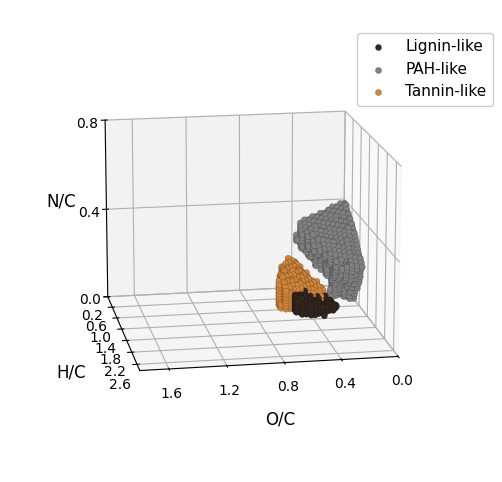

In [7]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['tannin','lignin','pah'])

idx = np.where([x in chosen_cats for x in y_pred_knn])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_knn[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.75, .95), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=15, azim=80)

fig.savefig(f'{save_plots_dir}\\knn_1.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

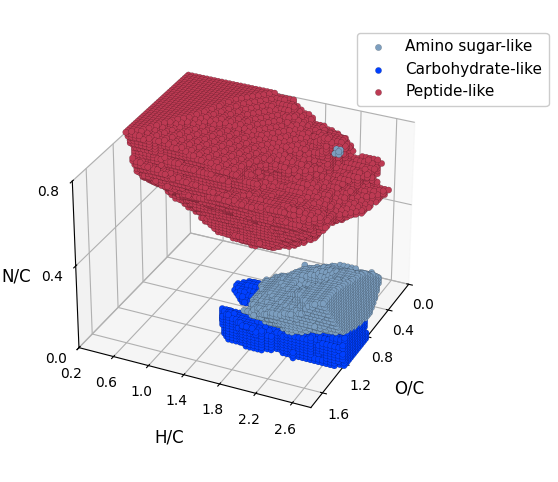

In [8]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['carbohydrate','peptide','amino_sugar'])

idx = np.where([x in chosen_cats for x in y_pred_knn])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_knn[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.75, .95), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=30, azim=25)

fig.savefig(f'{save_plots_dir}\\knn_2.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

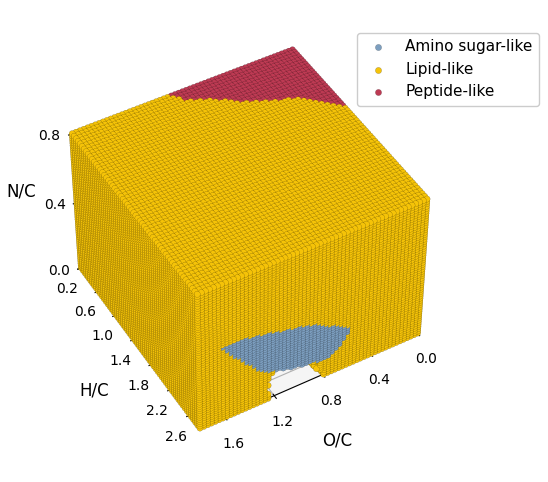

In [9]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['lipid','peptide','amino_sugar'])

idx = np.where([x in chosen_cats for x in y_pred_knn])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_knn[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.75, .95), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=45, azim=60)

fig.savefig(f'{save_plots_dir}\\knn_3-1.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

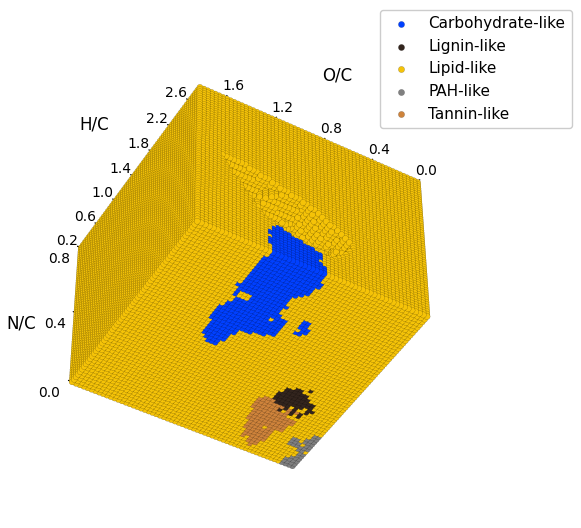

In [10]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['tannin','lignin','lipid','carbohydrate','pah'])

idx = np.where([x in chosen_cats for x in y_pred_knn])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_knn[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.8, 1.1), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=-45, azim=60)

fig.savefig(f'{save_plots_dir}\\knn_3-2.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

## GNB

In [11]:
y_pred_gnb = model_dict['gnb'].predict(grid)

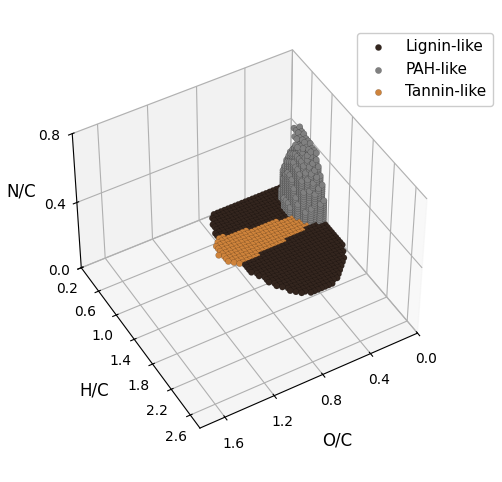

In [12]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['tannin','lignin','pah'])

idx = np.where([x in chosen_cats for x in y_pred_gnb])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_gnb[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.75, .95), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=45, azim=60)

fig.savefig(f'{save_plots_dir}\\gnb_1.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

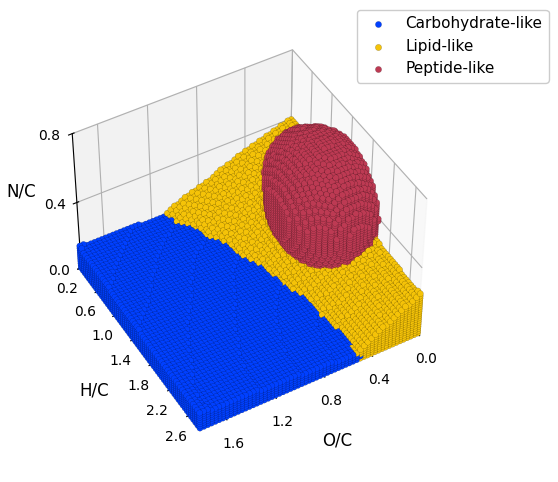

In [13]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['carbohydrate','lipid','peptide'])

idx = np.where([x in chosen_cats for x in y_pred_gnb])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_gnb[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.75, 1), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=45, azim=60)

fig.savefig(f'{save_plots_dir}\\gnb_2.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

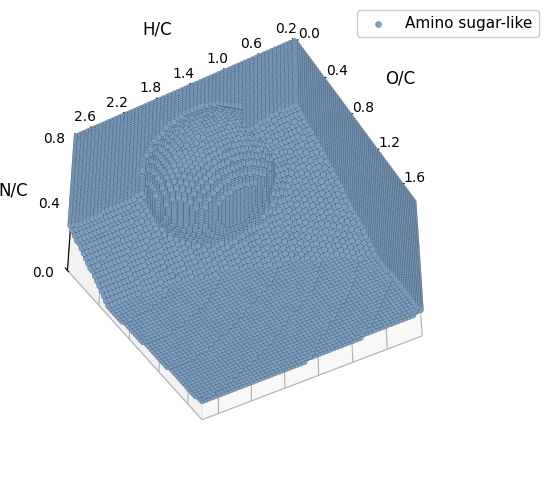

In [14]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['amino_sugar'])

idx = np.where([x in chosen_cats for x in y_pred_gnb])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_gnb[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.75, 1), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=-45, azim=210)

fig.savefig(f'{save_plots_dir}\\gnb_3.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

## Poly SVM

In [15]:
y_pred_svm_poly = model_dict['svm_poly'].predict(grid)

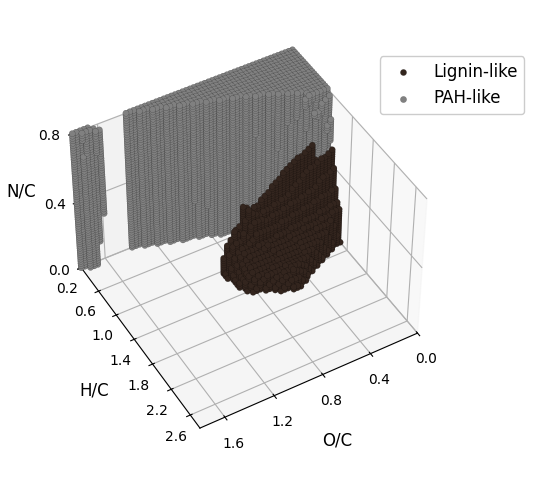

In [16]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['lignin','pah'])

idx = np.where([x in chosen_cats for x in y_pred_svm_poly])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_svm_poly[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.8, .9), loc='upper left', borderaxespad=0,fontsize=12)

ax.view_init(elev=45, azim=60)

fig.savefig(f'{save_plots_dir}\\svm_poly_1.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

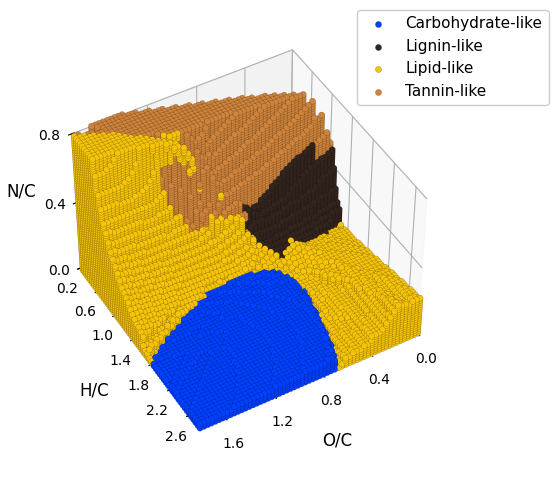

In [17]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['tannin','carbohydrate','lipid','lignin'])

idx = np.where([x in chosen_cats for x in y_pred_svm_poly])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_svm_poly[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.75, 1), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=45, azim=60)

fig.savefig(f'{save_plots_dir}\\svm_poly_2.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

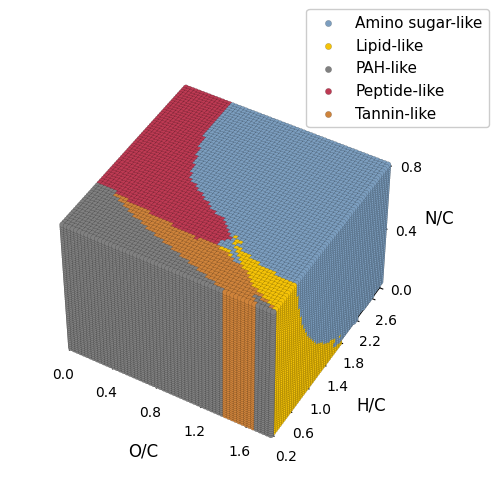

In [18]:
fig = plt.figure(figsize=(6,5.5))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['peptide','amino_sugar','lipid','pah','tannin'])

idx = np.where([x in chosen_cats for x in y_pred_svm_poly])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_svm_poly[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.7, 1.1), loc='upper left', borderaxespad=0,fontsize=11)

ax.view_init(elev=45, azim=-60)

fig.savefig(f'{save_plots_dir}\\svm_poly_3.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

## RBF SVM

In [19]:
y_pred_svm_rbf = model_dict['svm_rbf'].predict(grid)

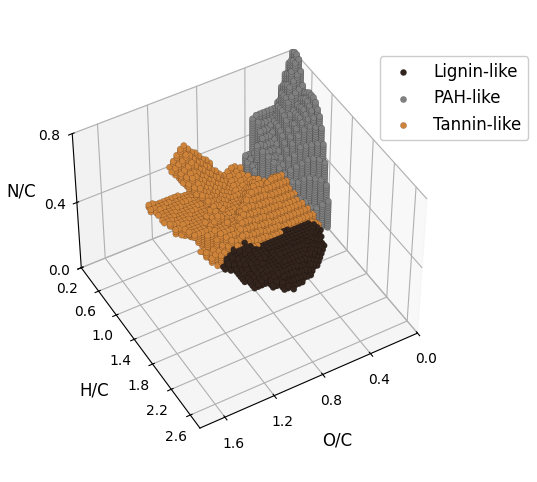

In [20]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['lignin','pah','tannin'])

idx = np.where([x in chosen_cats for x in y_pred_svm_rbf])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_svm_rbf[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.8, .9), loc='upper left', borderaxespad=0,fontsize=12)

ax.view_init(elev=45, azim=60)

fig.savefig(f'{save_plots_dir}\\svm_rbf_1.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

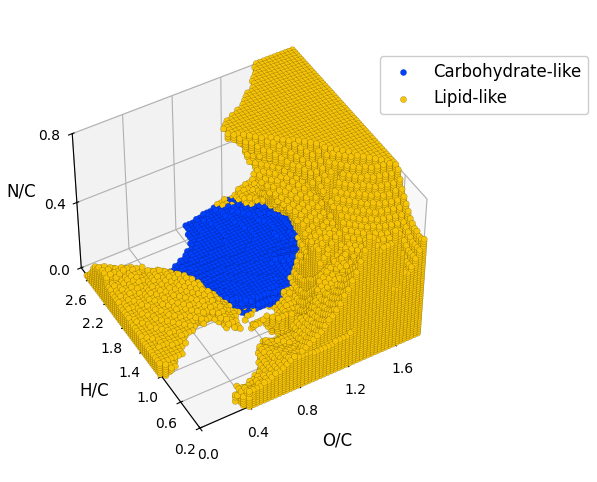

In [21]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['carbohydrate','lipid'])

idx = np.where([x in chosen_cats for x in y_pred_svm_rbf])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_svm_rbf[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.8, .9), loc='upper left', borderaxespad=0,fontsize=12)

ax.view_init(elev=45, azim=-120)

fig.savefig(f'{save_plots_dir}\\svm_rbf_2.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

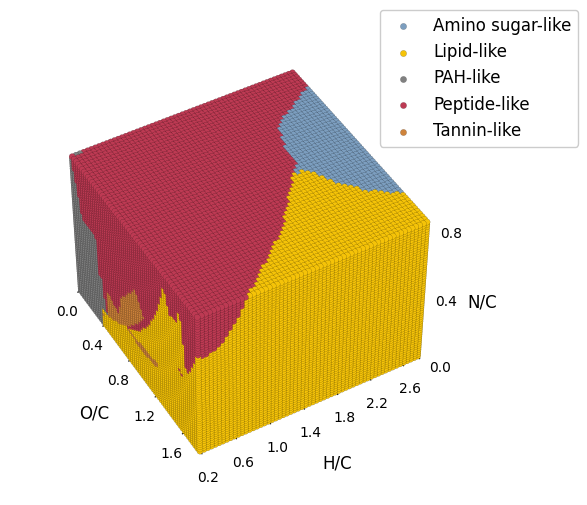

In [22]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['peptide','amino_sugar','lipid','pah','tannin'])

idx = np.where([x in chosen_cats for x in y_pred_svm_rbf])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_svm_rbf[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.8, 1.05), loc='upper left', borderaxespad=0,fontsize=12)

ax.view_init(elev=45, azim=-30)

fig.savefig(f'{save_plots_dir}\\svm_rbf_3-1.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')

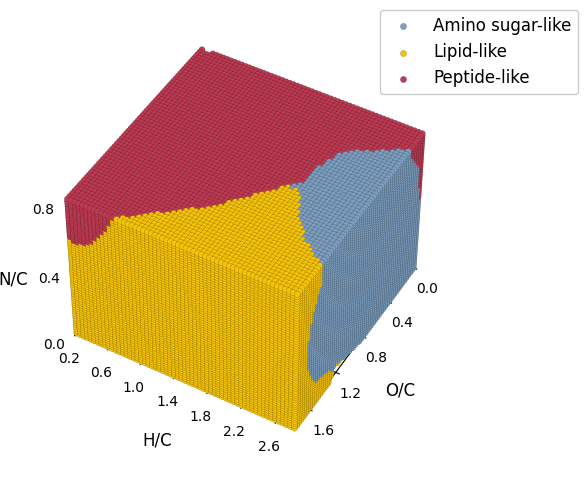

In [23]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

chosen_cats = np.sort(['peptide','amino_sugar','lipid'])

idx = np.where([x in chosen_cats for x in y_pred_svm_rbf])[0]
ax.scatter(xx[idx],yy[idx],zz[idx],c=[mlcf.vk_region_colours[x] for x in y_pred_svm_rbf[idx]],alpha=1,edgecolor='k',lw=.1,)

default_ax_features(ax,chosen_cats)

ax.legend(framealpha=1,bbox_to_anchor=(.8, 1), loc='upper left', borderaxespad=0,fontsize=12)

ax.view_init(elev=45, azim=30)

fig.savefig(f'{save_plots_dir}\\svm_rbf_3-2.{plot_format}',dpi=400, facecolor = '#fff', bbox_inches='tight')